# **DiwanNajd**


This project that aims to build a **language model** capable of understanding and generating text in the **Najdi** dialect of Arabic, with a particular focus on Arabic **poetry** and poetic interpretation. The model is implemented using a **decoder-only Transformer (GPT-style)** architecture built from scratch in **PyTorch**.

This project is divided into **two main phases**:

1. In the **first phase**, the model is pretrained on a corpus of Arabic text, including **Modern Standard Arabic (MSA)** and **classical poetry**, to learn the general structure and patterns of the language through next-token prediction.

2. In the **second phase**, the model is **fine-tuned** using a **supervised** instruction dataset, where each example contains an instruction, optional input, and a target response. This stage teaches the model to **follow instructions** such as explaining poetry, answering questions, and generating short poetic verses in the **Najdi** dialect.

The **goal** of **DiwanNajd** is to demonstrate the full lifecycle of building a language model, from data preparation and tokenization to model training, fine-tuning, and evaluation. All while exploring how transformer-based models can be adapted to **support regional Arabic** dialects and poetic language.

**Phase 1:** Pretraining

**1. Environment Setup and Library Imports**

In [ ]:
!pip -q install datasets transformers torch tqdm matplotlib

In [ ]:
from pathlib import Path
import random
import re
import math
import json

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer

**Project structure**

In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Project folders
BASE_DIR = Path("/content/diwan_najd_phase1")
DATA_DIR = BASE_DIR / "data"
TOKENIZER_DIR = BASE_DIR / "tokenizer"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
RESULTS_DIR = BASE_DIR / "results"

for folder in [DATA_DIR, TOKENIZER_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

Device: cuda


**HyperParameters**

In [ ]:
NUM_MSA = 4000
NUM_POETRY = 6000

VAL_RATIO = 0.1

SPECIAL_TOKENS = {
    "bos_token": "[BOS]",
    "eos_token": "[EOS]",
    "pad_token": "[PAD]"
}

MAX_LENGTH = 128
STRIDE = 64
BATCH_SIZE = 8

PRETRAIN_EPOCHS = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
EVAL_STEPS = 100

**2. Load the datasets**



In [ ]:
# MSA dataset
msa = load_dataset(
    "Omartificial-Intelligence-Space/FineWeb2-MSA",
    split="train",
    streaming=True
)

# Poetry dataset
poetry = load_dataset(
    "qafiyah/classical-arabic-poetry",
    split="train"
)

print("Poetry columns:", poetry.column_names)
print("Poetry size:", len(poetry))
print(poetry[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/94 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/84329 [00:00<?, ? examples/s]

Poetry columns: ['poem_id', 'poem_slug', 'title', 'content', 'poet_name', 'poet_slug', 'poet_bio', 'era_name', 'era_slug', 'meter_name', 'meter_slug', 'theme_name', 'theme_slug', 'rhyme_pattern', 'verses', 'text']
Poetry size: 84329
{'poem_id': 78537, 'poem_slug': '92c5a390-5d38-4aac-89a0-5449a76a94d6', 'title': 'لم تبغ همتك المحل العالي', 'content': 'لَم تَبغِ هِمَّتُكَ المَحَلَّ العالي*إِلّا وَأَنتَ مُوَفَّقٌ لِكَمالِ*وَكَذاكَ ما عَشِقَت خَلائِقُكَ العُلى*إِلّا وَلِلأَموالِ قَلبُكَ قالي*أَمُجَدِّلَ الأَبطالِ بَل يا باذِلَ ال*أَموالِ بَل يا حامِلَ الأَثقالِ*صَيَّرتَ أَسحارَ السَماحِ بَواكِراً*وَجَعَلتَ أَيّامَ الكِفاحِ لَيالي*بِحَماسَةٍ مَقرونَةٍ بِسَماحَةٍ*وَجَلادَةٍ مَشفوعَةٍ بِجِدالِ*تُحمي الجِوارَ مِنَ الحَوادِثِ مِثلَما*يَحمي فَريسَتَهُ أَبو الأَشبالِ*أَغياثَ دينِ اللَهِ يا مَن رَأيُه*يُغنيهِ عَن خَطِّيَّةٍ وَنِصالِ*ما كُنتُ أَعلَمُ قَبلَ لُحتَ لِناظِري*أَنَّ الخُيولَ تَسيرُ بِالأَجبالِ*طاوَعتُ فيكَ تَفَرُّسي وَتَوَسُّمي*وَعَصَيتَ فيكَ مَلامَةَ العُذّالِ*ما زِلتُ مِنذُ سَرى رُكاب

**Clean the text**

In [ ]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.strip()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove emails
    text = re.sub(r"\S+@\S+", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def is_valid_text(text: str) -> bool:
    if not text:
        return False

    if len(text) < 30:
        return False

    arabic_chars = len(re.findall(r"[\u0600-\u06FF]", text))
    if arabic_chars < 15:
        return False

    # Reject obvious junk
    if "||" in text:
        return False

    if re.search(r"\b\d{1,2}-\d{1,2}-\d{2,4}\b", text):
        return False

    if re.search(r"\b\d{1,2}:\d{2}\b", text):
        return False

    non_arabic = len(re.findall(r"[^ \u0600-\u06FF]", text))
    if non_arabic > arabic_chars:
        return False

    return True

**Collect text / Prepare dataset for tokenization**

In [ ]:
def collect_stream_texts(dataset_stream, target_n, text_col="text"):
    collected = []

    for row in dataset_stream:
        if text_col not in row:
            continue

        text = clean_text(row[text_col])
        if is_valid_text(text):
            collected.append(text)

        if len(collected) >= target_n:
            break

    return collected


def collect_dataset_texts(dataset, target_n, text_col="text"):
    dataset_small = dataset.shuffle(seed=SEED).select(range(min(target_n, len(dataset))))
    texts = []

    for row in dataset_small:
        if text_col not in row:
            continue

        text = clean_text(row[text_col])
        if is_valid_text(text):
            texts.append(text)

    return texts


msa_texts = collect_stream_texts(msa, NUM_MSA, text_col="text")
poetry_texts = collect_dataset_texts(poetry, NUM_POETRY, text_col="text")

print("Collected MSA:", len(msa_texts))
print("Collected Poetry:", len(poetry_texts))

Collected MSA: 4000
Collected Poetry: 5987


**Print sample data**

In [ ]:
print("MSA sample:\n", msa_texts[0][:800])
print("\nPoetry sample:\n", poetry_texts[0][:800])

MSA sample:
 السبيل لحل أزمة القيادة الفلسطينية بلغ الانهيار البطيء لمؤسسات القيادة الفلسطينية الجماعية في السنوات الأخيرة حد الأزمة في خضمّ الثوارت العربية الجارية، والتجليات في وثائق فلسطين، وغياب أي عملية سلام ذات مصداقية. لقد سعت السلطة الفلسطينية في رام الله التي يسيطر عليها محمود عباس وحركة فتح التابعة له للاستجابة لهذه الأزمة بالدعوة إلى إجراء انتخابات تشريعية ورئاسية، حيث يأمل عباس أن تعيد الانتخابات، الشرعية لقيادته. أما حركة المقاومة الإسلامية حماس فقد رفضت إجراء هذه الانتخابات في ظل غياب اتفاق مصالحة، ينهي الانقسام الذي نجم عن رفض حركة فتح (وإسرائيل والرعاة الغربيين للسلطة الفلسطينية، ولا سيما الولايات المتحدة) قبول نتيجة الانتخابات الأخيرة التي أجريت في عام 2006، والتي حسمتها حركة حماس لصالحها. وحتى لو عُقدت انتخابات من هذا القبيل في الضفة الغربـــية وقطاع غزة فإنها لن تحل أزمة القيادة الجم

Poetry sample:
 قالت سليمى إنني لا أبغيه أراه شيخاً عارياً تراقيه محمرة من كبر مآقيه ترعية قد ذرئت مجاليه رأت غلاما جاهلا تصابيه يقلي الغواني والغواني تقليه أحب ما اصطاد مكان يخليه ذو ذ

**3. Build a small balanced corpus**

In [ ]:
random.shuffle(msa_texts)
random.shuffle(poetry_texts)

pretrain_texts = msa_texts + poetry_texts
random.shuffle(pretrain_texts)

print("Pretraining corpus size:", len(pretrain_texts))

Pretraining corpus size: 9987


**4. Split data**

In [ ]:
def split_texts(texts, val_ratio=0.1):
    split_idx = int(len(texts) * (1 - val_ratio))
    return texts[:split_idx], texts[split_idx:]


pretrain_train, pretrain_val = split_texts(pretrain_texts, VAL_RATIO)

print("Train size:", len(pretrain_train))
print("Val size:", len(pretrain_val))

Train size: 7989
Val size: 1998


**Save files**

In [ ]:
pretrain_train_path = DATA_DIR / "pretrain_train.txt"
pretrain_val_path = DATA_DIR / "pretrain_val.txt"
tokenizer_corpus_path = DATA_DIR / "tokenizer_corpus.txt"

def save_texts(path, texts):
    with open(path, "w", encoding="utf-8") as f:
        for t in texts:
            f.write(t + "\n")

save_texts(pretrain_train_path, pretrain_train)
save_texts(pretrain_val_path, pretrain_val)
save_texts(tokenizer_corpus_path, pretrain_train)

print("Saved files:")
print(pretrain_train_path)
print(pretrain_val_path)
print(tokenizer_corpus_path)

Saved files:
/content/diwan_najd_phase1/data/pretrain_train.txt
/content/diwan_najd_phase1/data/pretrain_val.txt
/content/diwan_najd_phase1/data/tokenizer_corpus.txt


**5. Tokenization**

We imported a tokenizer that supports **Arabic UTF-8 text**, and splits words into **meaningful subword** units

In [ ]:
hf_tokenizer = AutoTokenizer.from_pretrained("faisalq/SaudiBERT")

hf_tokenizer.add_special_tokens(SPECIAL_TOKENS)

TOKENIZER_SAVE_DIR = TOKENIZER_DIR / "saudibert_tokenizer"
hf_tokenizer.save_pretrained(str(TOKENIZER_SAVE_DIR))

print("Tokenizer base vocab size:", hf_tokenizer.vocab_size)
print("Tokenizer total size after added tokens:", len(hf_tokenizer))
print("Saved tokenizer to:", TOKENIZER_SAVE_DIR)

config.json:   0%|          | 0.00/630 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

Tokenizer base vocab size: 75000
Tokenizer total size after added tokens: 75003
Saved tokenizer to: /content/diwan_najd_phase1/tokenizer/saudibert_tokenizer


**Tokenizer Wrapper**

The wrapper standardizes **how text is encoded** into **token IDs** and **decoded** back into text, while also exposing important **special token IDs** used during **training**.

In [ ]:
class HFTokenizerWrapper:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer
        self.pad_id = tokenizer.pad_token_id
        self.unk_id = tokenizer.unk_token_id
        self.bos_id = tokenizer.bos_token_id
        self.eos_id = tokenizer.eos_token_id

    def encode(self, text, add_special_tokens=True):
        ids = self.tokenizer.encode(text, add_special_tokens=False)
        if add_special_tokens:
            ids = [self.bos_id] + ids + [self.eos_id]
        return ids

    def decode(self, ids):
        return self.tokenizer.decode(ids, skip_special_tokens=True)

tok = HFTokenizerWrapper(hf_tokenizer)

test_text = "البيت يحث على الطموح ويقول إن اللي يبي المعالي لازم يتعب"
ids = tok.encode(test_text)
print(ids[:30])
print(tok.decode(ids))
print(hf_tokenizer.tokenize(test_text))

[75000, 697, 34774, 18, 11809, 1300, 19, 44, 628, 35733, 302, 9035, 75001]
البيت يحث على الطموح ويقول ان اللي يبي المعالي لازم يتعب
['▁البيت', '▁يحث', '▁على', '▁الطموح', '▁ويقول', '▁ان', '▁اللي', '▁يبي', '▁المعالي', '▁لازم', '▁يتعب']


**Example 1**

In [ ]:
text = "البيت يحث على الطموح ويقول إن اللي يبي المعالي لازم يتعب"

ids = tok.encode(text)

tokens = tok.tokenizer.tokenize(text)

print("Token IDs:", ids)
print("Tokens:", tokens)

Token IDs: [75000, 697, 34774, 18, 11809, 1300, 19, 44, 628, 35733, 302, 9035, 75001]
Tokens: ['▁البيت', '▁يحث', '▁على', '▁الطموح', '▁ويقول', '▁ان', '▁اللي', '▁يبي', '▁المعالي', '▁لازم', '▁يتعب']


**Example 2**

In [ ]:
text = "قفا نبك من ذكرى حبيب ومنزل"

print(tok.tokenizer.tokenize(text))

['▁قفا', '▁', 'ن', 'ب', 'ك', '▁من', '▁ذكرى', '▁حبيب', '▁ومنزل']


**6. Creating the Pretraining DataLoader**

The **pretraining dataset** is converted into **fixed-length** sequences of tokens. Each sequence is used to predict the next token in the sequence, enabling the model to learn **language patterns**.

In [ ]:
class GPTTextDataset(Dataset):
    def __init__(self, txt_path, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        with open(txt_path, "r", encoding="utf-8") as f:
            txt = f.read()

        token_ids = tokenizer.encode(txt, add_special_tokens=False)

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1:i + max_length + 1]

            self.input_ids.append(torch.tensor(input_chunk, dtype=torch.long))
            self.target_ids.append(torch.tensor(target_chunk, dtype=torch.long))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader(txt_path, tokenizer, batch_size=8, max_length=128, stride=64,
                      shuffle=True, drop_last=True, num_workers=0):
    dataset = GPTTextDataset(txt_path, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    return dataloader


train_loader = create_dataloader(
    pretrain_train_path, tok,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
    stride=STRIDE,
    shuffle=True
)

val_loader = create_dataloader(
    pretrain_val_path, tok,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
    stride=STRIDE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Token indices sequence length is longer than the specified maximum sequence length for this model (1022540 > 512). Running this sequence through the model will result in indexing errors


Train batches: 1997
Val batches: 463


**7. GPT Architecture - Decoder-Only Transformer**

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi, device=x.device)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

**8. Training Loss Computation**

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)
    loss = nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0

    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    model.eval()
    with torch.no_grad():
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i >= num_batches:
                break
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()

    model.train()
    return total_loss / num_batches

**9. Text Generation**

In [ ]:
def generate_text(model, tokenizer, prompt, max_new_tokens=30, temperature=0.6, top_k=5):
    model.eval()

    prompt_ids = tokenizer.encode(prompt)
    idx = torch.tensor([prompt_ids], dtype=torch.long).to(device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -GPT_CONFIG["context_length"]:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, top_indices = torch.topk(logits, top_k)
            probs = torch.softmax(top_logits / temperature, dim=-1)
            next_token_relative = torch.multinomial(probs, num_samples=1)
            next_token = top_indices.gather(-1, next_token_relative)
        else:
            probs = torch.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        idx = torch.cat((idx, next_token), dim=1)

    generated_ids = idx[0].tolist()[len(prompt_ids):]
    return tokenizer.decode(generated_ids)

**Architecture Configuration**

In [ ]:
GPT_CONFIG = {
    "vocab_size": len(hf_tokenizer), # how many unique tokens the model can recognize.

    "context_length": MAX_LENGTH, # maximum number of tokens the model can read at once.

    "emb_dim": 256, # size of the vector representation of each token

    "n_heads": 8, # Self-attention is split into multiple heads

    "n_layers": 4, # how many Transformer blocks the model has.

    "drop_rate": 0.1, # randomly disables neurons during training to prevent overfitting

    "qkv_bias": False, # query, key, and value projections in attention layers include bias terms
}

**10. Train model**

**During training:** the model predicts the next token in each sequence, **cross-entropy loss** measures prediction accuracy, **gradients** are updated using backpropagation. **Loss curves** are monitored to track learning progress.

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, device,
                epochs, eval_steps=100):
    train_losses = []
    val_losses = []
    global_step = 0

    model.train()

    for epoch in range(epochs):
        progress = tqdm(train_loader, desc=f"Pretraining | epoch {epoch+1}/{epochs}")

        for input_batch, target_batch in progress:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            global_step += 1

            if global_step % eval_steps == 0:
                train_loss = calc_loss_loader(train_loader, model, device, num_batches=20)
                val_loss = calc_loss_loader(val_loader, model, device, num_batches=20)

                train_losses.append(train_loss)
                val_losses.append(val_loss)

                progress.set_postfix({
                    "step": global_step,
                    "train_loss": round(train_loss, 4),
                    "val_loss": round(val_loss, 4)
                })

    return train_losses, val_losses

In [ ]:
model = GPTModel(GPT_CONFIG).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(model)

GPTModel(
  (tok_emb): Embedding(75003, 256)
  (pos_emb): Embedding(128, 256)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=256, out_features=256, bias=False)
        (W_key): Linear(in_features=256, out_features=256, bias=False)
        (W_value): Linear(in_features=256, out_features=256, bias=False)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU()
          (2): Linear(in_features=1024, out_features=256, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

**11. Pretraining Process**

In [ ]:
train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=PRETRAIN_EPOCHS,
    eval_steps=EVAL_STEPS
)

Pretraining | epoch 1/5:   0%|          | 0/1997 [00:00<?, ?it/s]

Pretraining | epoch 2/5:   0%|          | 0/1997 [00:00<?, ?it/s]

Pretraining | epoch 3/5:   0%|          | 0/1997 [00:00<?, ?it/s]

Pretraining | epoch 4/5:   0%|          | 0/1997 [00:00<?, ?it/s]

Pretraining | epoch 5/5:   0%|          | 0/1997 [00:00<?, ?it/s]

**12. Save the model**

In [ ]:
pretrained_ckpt = CHECKPOINT_DIR / "phase1_pretrained_model.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": GPT_CONFIG
}, pretrained_ckpt)

print("Saved pretrained model:", pretrained_ckpt)

Saved pretrained model: /content/diwan_najd_phase1/checkpoints/phase1_pretrained_model.pt


**13. Test the Model**

In [ ]:
prompts = [
    "قال الشاعر",
    "في معنى الحب",
    "القصيدة تقول",
    "يا ليل"
]

for p in prompts:
    print("=" * 80)
    print("PROMPT:", p)
    print(generate_text(model, tok, p, max_new_tokens=40, temperature=0.6, top_k=10))

PROMPT: قال الشاعر
من نواظرات وطلاق ووناب منه على نضوبا هجان اين وابليس اهن
PROMPT: في معنى الحب
. واتصالات. و تشمل في للن و الشرق الاوسط»، وبالفعل وعلاقتي هذه ومحاضرات وهندسية الكونغرس و و و روساء
PROMPT: القصيدة تقول
. و الانجيل ان المسيح شييا. يا ايها الراحل من امه يا ابا حسن ام يا ايها الملك عبد الرحيم يا ايها الملك الذي قد يبك يا سيدي يا
PROMPT: يا ليل
من كال هل متصرف ام ام وحمى مثلك لظمايا فنا لن ام ف


**14. Training Loss Vs. Validation Loss**

-

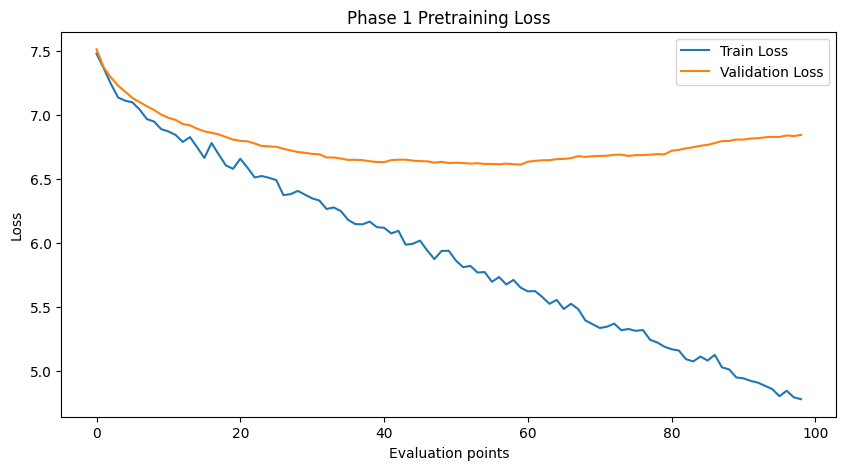

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation points")
plt.ylabel("Loss")
plt.title("Phase 1 Pretraining Loss")
plt.legend()
plt.show()

**Interpretation:**

**Pretraining Loss Analysis**

- **Training loss decreases steadily** throughout the pretraining phase, indicating that the model is successfully learning language patterns from the training dataset.

- **Validation loss initially decreases**, which shows that the model is able to generalize what it learns to unseen data.

- **After the midpoint of training, the validation loss slightly increases** while the **training loss continues to decrease**. This indicates the beginning of mild **overfitting**, which is **expected** when the model starts fitting the training data more closely than the validation data.

- This behavior is **normal in the pretraining stage**, especially when the dataset is relatively small compared to the model capacity.

- In the next stage, **Supervised Fine-Tuning (SFT)** will refine the model using **instruction–response pairs**. This stage helps the model learn how to follow instructions, generate coherent responses, and produce text in the Najdi dialect, which will **significantly improve generation quality**.

**Phase 2: Supervised Fine-Tuning**

**Paths and Settings**

In [ ]:
BASE_DIR = Path("/content/diwan_najd_phase1")
TOKENIZER_DIR = BASE_DIR / "tokenizer"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"

SFT_FILE = Path("/content/diwan_najd_phase1/data/najdi_sft_500.jsonl")

TOKENIZER_SAVE_DIR = TOKENIZER_DIR / "saudibert_tokenizer"
pretrained_ckpt = CHECKPOINT_DIR / "phase1_pretrained_model.pt"
sft_ckpt = CHECKPOINT_DIR / "phase2_sft_model.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

SFT_MAX_LENGTH = 128
SFT_BATCH_SIZE = 4
SFT_EPOCHS = 8
SFT_LEARNING_RATE = 1e-4
SFT_WEIGHT_DECAY = 0.01
SFT_EVAL_STEPS = 20
VAL_SIZE = 100

print("SFT file exists:", SFT_FILE.exists())
print("Tokenizer exists:", TOKENIZER_SAVE_DIR.exists())
print("Checkpoint exists:", pretrained_ckpt.exists())

SFT file exists: True
Tokenizer exists: True
Checkpoint exists: True


**1. Load JSONL file**

In [ ]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

sft_records = load_jsonl(SFT_FILE)

print("Number of SFT examples:", len(sft_records))
print(sft_records[0])

Number of SFT examples: 500
{'instruction': 'وش معنى هالبيت؟', 'input': 'إذا غامرتَ في شرفٍ مرومِ', 'output': 'البيت يقصد إن اللي يبي المعالي ما يرضى بالقليل، ولازم يغامر ويتعب عشان يوصل.'}


**2. Split Data**

In [ ]:
random.seed(42)
random.shuffle(sft_records)

val_records = sft_records[:VAL_SIZE]
train_records = sft_records[VAL_SIZE:]

print("Train SFT size:", len(train_records))
print("Val SFT size:", len(val_records))

Train SFT size: 400
Val SFT size: 100


**3. Building the Supervised Fine-Tuning (SFT) Dataset**

In [ ]:
class SFTDataset(Dataset):
    def __init__(self, records, tokenizer, max_length=128):
        self.samples = []
        self.tokenizer = tokenizer
        self.max_length = max_length

        for record in records:
            instruction = record.get("instruction", "").strip()
            input_text = record.get("input", "").strip()
            output_text = record.get("output", "").strip()

            if input_text:
                prompt = (
                    f"instruction:\n{instruction}\n\n"
                    f"input:\n{input_text}\n\n"
                    f"output:\n"
                )
            else:
                prompt = (
                    f"instruction:\n{instruction}\n\n"
                    f"output:\n"
                )

            full_text = prompt + output_text

            prompt_ids = tokenizer.encode(prompt, add_special_tokens=True)
            full_ids = tokenizer.encode(full_text, add_special_tokens=True)

            full_ids = full_ids[:max_length]

            if len(full_ids) < 2:
                continue

            input_ids = full_ids[:-1]
            labels = full_ids[1:].copy()

            # number of prompt tokens that should be ignored in the loss
            prompt_len = min(len(prompt_ids) - 1, len(labels))

            # mask prompt tokens with -100, not pad_id
            for i in range(prompt_len):
                labels[i] = -100

            self.samples.append((
                torch.tensor(input_ids, dtype=torch.long),
                torch.tensor(labels, dtype=torch.long)
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

**4. Creating the SFT DataLoader and Batch Padding**

In [ ]:
def sft_collate_fn(batch, pad_id):
    input_tensors, label_tensors = zip(*batch)

    max_len = max(len(x) for x in input_tensors)

    padded_inputs = []
    padded_labels = []

    for inp, lab in zip(input_tensors, label_tensors):
        inp_pad_len = max_len - len(inp)
        lab_pad_len = max_len - len(lab)

        padded_inputs.append(
            torch.cat([inp, torch.full((inp_pad_len,), pad_id, dtype=torch.long)])
        )
        padded_labels.append(
            torch.cat([lab, torch.full((lab_pad_len,), pad_id, dtype=torch.long)])
        )

    return torch.stack(padded_inputs), torch.stack(padded_labels)


train_dataset = SFTDataset(train_records, tok, max_length=SFT_MAX_LENGTH)
val_dataset = SFTDataset(val_records, tok, max_length=SFT_MAX_LENGTH)

sft_train_loader = DataLoader(
    train_dataset,
    batch_size=SFT_BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda batch: sft_collate_fn(batch, tok.pad_id)
)

sft_val_loader = DataLoader(
    val_dataset,
    batch_size=SFT_BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda batch: sft_collate_fn(batch, tok.pad_id)
)

print("Train SFT batches:", len(sft_train_loader))
print("Val SFT batches:", len(sft_val_loader))

Train SFT batches: 100
Val SFT batches: 25


In [ ]:
GPT_CONFIG = {
    "vocab_size": len(hf_tokenizer),
    "context_length": MAX_LENGTH,
    "emb_dim": 256,
    "n_heads": 8,
    "n_layers": 4,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

**GPT Model Code**

In [ ]:
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi, device=x.device)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

**5. Load the Phase 1 pretrained checkpoint**

In [ ]:
model = GPTModel(GPT_CONFIG).to(device)

checkpoint = torch.load(pretrained_ckpt, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded Phase 1 checkpoint successfully.")

Loaded Phase 1 checkpoint successfully.


**6. Loss Function for Masked SFT**

In [ ]:
def calc_sft_loss_batch(input_batch, label_batch, model, device):
    input_batch = input_batch.to(device)
    label_batch = label_batch.to(device)

    logits = model(input_batch)

    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        label_batch.view(-1),
        ignore_index=-100
    )
    return loss


def calc_sft_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0

    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    model.eval()
    with torch.no_grad():
        for i, (input_batch, label_batch) in enumerate(data_loader):
            if i >= num_batches:
                break
            loss = calc_sft_loss_batch(input_batch, label_batch, model, device)
            total_loss += loss.item()

    model.train()
    return total_loss / num_batches

**7. Training Loop**

In [ ]:
def train_sft_model(model, train_loader, val_loader, optimizer, device,
                    epochs, eval_steps):
    train_losses = []
    val_losses = []
    global_step = 0

    model.train()

    for epoch in range(epochs):
        progress = tqdm(train_loader, desc=f"SFT | epoch {epoch+1}/{epochs}")

        for input_batch, label_batch in progress:
            optimizer.zero_grad()

            loss = calc_sft_loss_batch(input_batch, label_batch, model, device)
            loss.backward()
            optimizer.step()

            global_step += 1

            if global_step % eval_steps == 0:
                train_loss = calc_sft_loss_loader(
                    train_loader, model, device, num_batches=10
                )
                val_loss = calc_sft_loss_loader(
                    val_loader, model, device, num_batches=10
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)

                progress.set_postfix({
                    "step": global_step,
                    "train_loss": round(train_loss, 4),
                    "val_loss": round(val_loss, 4)
                })

    return train_losses, val_losses

**8. Optimizer**

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=SFT_LEARNING_RATE,
    weight_decay=SFT_WEIGHT_DECAY
)

**9. Training SFT Process**

In [ ]:
sft_train_losses, sft_val_losses = train_sft_model(
    model=model,
    train_loader=sft_train_loader,
    val_loader=sft_val_loader,
    optimizer=optimizer,
    device=device,
    epochs=SFT_EPOCHS,
    eval_steps=SFT_EVAL_STEPS
)

SFT | epoch 1/8:   0%|          | 0/100 [00:00<?, ?it/s]

SFT | epoch 2/8:   0%|          | 0/100 [00:00<?, ?it/s]

SFT | epoch 3/8:   0%|          | 0/100 [00:00<?, ?it/s]

SFT | epoch 4/8:   0%|          | 0/100 [00:00<?, ?it/s]

SFT | epoch 5/8:   0%|          | 0/100 [00:00<?, ?it/s]

SFT | epoch 6/8:   0%|          | 0/100 [00:00<?, ?it/s]

SFT | epoch 7/8:   0%|          | 0/100 [00:00<?, ?it/s]

SFT | epoch 8/8:   0%|          | 0/100 [00:00<?, ?it/s]

**10. Save the New Model**

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": GPT_CONFIG
}, sft_ckpt)

print("Saved SFT model to:", sft_ckpt)

Saved SFT model to: /content/diwan_najd_phase1/checkpoints/phase2_sft_model.pt


**11. Generation function**

- Must only decode the newly generated tokens, not the prompt itself.

In [ ]:
def generate_text(model, tokenizer, prompt, max_new_tokens=30, temperature=0.4, top_k=3):
    model.eval()

    prompt_ids = tokenizer.encode(prompt)
    idx = torch.tensor([prompt_ids], dtype=torch.long).to(device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -GPT_CONFIG["context_length"]:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, top_indices = torch.topk(logits, top_k)
            probs = torch.softmax(top_logits / temperature, dim=-1)
            next_token_relative = torch.multinomial(probs, num_samples=1)
            next_token = top_indices.gather(-1, next_token_relative)
        else:
            probs = torch.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        idx = torch.cat((idx, next_token), dim=1)

    generated_ids = idx[0].tolist()[len(prompt_ids):]
    return tokenizer.decode(generated_ids)

**12. Plot SFT loss**

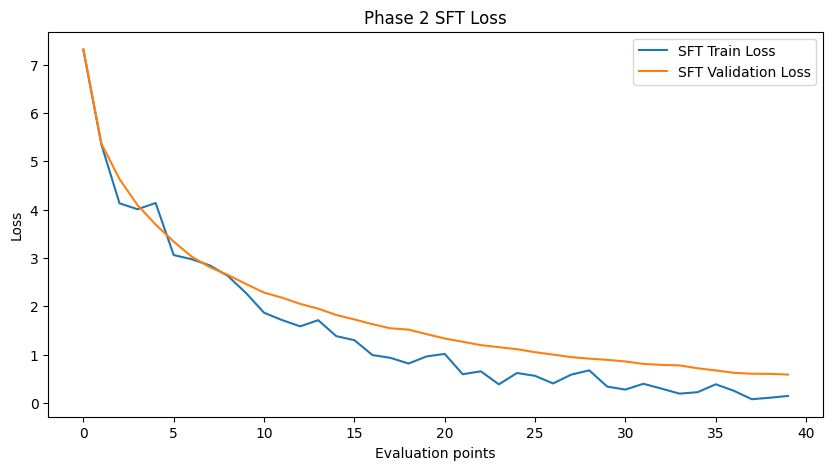

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(sft_train_losses, label="SFT Train Loss")
plt.plot(sft_val_losses, label="SFT Validation Loss")
plt.xlabel("Evaluation points")
plt.ylabel("Loss")
plt.title("Phase 2 SFT Loss")
plt.legend()
plt.show()

**13. Test prompts**

In [ ]:
test_prompts = [
    "instruction:\nاشرح معنى البيت التالي باللهجة النجدية.\n\ninput:\nإذا غامرتَ في شرفٍ مرومِ\n\noutput:\n",
    "instruction:\nوش معنى هالبيت؟ اشرح باللهجة النجدية.\n\ninput:\nقفا نبكِ من ذكرى حبيبٍ ومنزلِ\n\noutput:\n",
    "instruction:\nاكتب بيتين شعر باللهجة النجدية عن الشوق.\n\noutput:\n",
    "instruction:\nجاوب المستخدم باللهجة النجدية.\n\ninput:\nوش الفرق بين الشوق والحنين في الشعر؟\n\noutput:\n",
]

for i, p in enumerate(test_prompts, 1):
    output = generate_text(model, tok, p, max_new_tokens=80, temperature=0.6, top_k=5)

    print("=" * 100)
    print(f"Example {i}")
    print("-" * 100)
    print("PROMPT:")
    print(p)
    print("-" * 100)
    print("OUTPUT:")
    print(output.strip())
    print()

Example 1
----------------------------------------------------------------------------------------------------
PROMPT:
instruction:
اشرح معنى البيت التالي باللهجة النجدية.

input:
إذا غامرتَ في شرفٍ مرومِ

output:

----------------------------------------------------------------------------------------------------
OUTPUT:
سهل كان كل نقص........ وقت الشدة........ على اللي راح للي ما يقدرها الا اصحاب الهمم القوية. يلقى وفا..ها الا اصحاب الهمم القوية. من طول الليل، وحاس ان الهم مخليه اطول من

Example 2
----------------------------------------------------------------------------------------------------
PROMPT:
instruction:
وش معنى هالبيت؟ اشرح باللهجة النجدية.

input:
قفا نبكِ من ذكرى حبيبٍ ومنزلِ

output:

----------------------------------------------------------------------------------------------------
OUTPUT:
التعلم اخف من ذل الجهل الطويل...... قوية من طول عمره اقل من طموحه. على اثر الحبيب والمكان القديم، وفيه حنين وحزن على اللي راح.ها الا اصحاب الهمم للتعذيب..ها الا اصحاب الهمم القوي

**14. Parameters**

In [87]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 41,590,784
Trainable parameters: 41,590,784
